# Day 31 Klasifikasi Bungan IRIS ( Multi-Class ) dengan K-Nearest Neighbor

Setelah klasifikasi **dua kelas** (biner), kini kita naik level ke klasifikasi
**multi-class** (lebih dari dua kelas). Kita pakai dataset legendaris **Iris** dan algoritma intuitif **K-Nearest Neighbors (KNN)** — yang mengklasifikasikan data baru berdasarkan "tetangga" terdekatnya.

> 🎯 **Tujuan Pembelajaran**
> - Memahami cara kerja **KNN** untuk klasifikasi multi-class.
> - Mengetahui mengapa **scaling** penting untuk KNN (berbasis jarak).
> - Mencari **nilai k terbaik** dengan looping & visualisasi.
> - Mengevaluasi dengan **confusion matrix** & **classification_report**.

## Tentang Dataset

**Iris Dataset** berisi pengukuran 150 bunga dari 3 spesies. Target: **`Species`** (3 kelas: setosa, versicolor, virginica).

- **Sumber:** [Kaggle — uciml/iris](https://www.kaggle.com/datasets/uciml/iris)
- **Jumlah data:** 150 baris × 6 kolom

| Kolom | Arti |
|-------|------|
| `SepalLengthCm`, `SepalWidthCm` | Ukuran kelopak (sepal) |
| `PetalLengthCm`, `PetalWidthCm` | Ukuran mahkota (petal) |
| `Species` | **(Target)** 3 spesies bunga |

## Import Library


- **pandas / numpy** → olah data.
- **matplotlib / seaborn** → visualisasi & confusion matrix.
- **scikit-learn** → `KNeighborsClassifier`, `StandardScaler`, `LabelEncoder`,
  split, dan metrik klasifikasi.

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay, accuracy_score

In [23]:
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Import Dataset

In [24]:
!pip install kaggle
!kaggle datasets download -d uciml/iris
!unzip iris.zip

Dataset URL: https://www.kaggle.com/datasets/uciml/iris
License(s): CC0-1.0
iris.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  iris.zip
replace Iris.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: Iris.csv                
replace database.sqlite? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: database.sqlite         


## Eksplorasi Awal Dataset

In [25]:
df = pd.read_csv("Iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


Interpretasi:
-  Empat fitur numerik (ukuran sepal & petal) dan satu kolom target `Species` berupa teks.
- Ada kolom `Id` yang tidak berguna untuk modeling.

In [26]:
print("Bentuk Data:", df.shape)

df["Species"].value_counts()

Bentuk Data: (150, 6)


,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


Interpertasi:
- data terdiri dari 150 baris dan 6 kolom
- untuk kolom target, terdiri dari 3 kategori dengan proporsi yang sama ( Balanced )

In [27]:
df.isna().sum().sum()

np.int64(0)

Interpretasi:
- Tidak terdapat missing value
- Data sudah bersih dan siap digunakan

## Eksplorasi Data Analysis dan Visualisasi Data

### a) Sebaran Spesies ( Countplot )

/tmp/ipykernel_575/45671615.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df,
/tmp/ipykernel_575/45671615.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(i, df["Species"].value_counts()[i],
/tmp/ipykernel_575/45671615.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  df["Species"].value_counts()[i],
/tmp/ipykernel_575/45671615.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys 

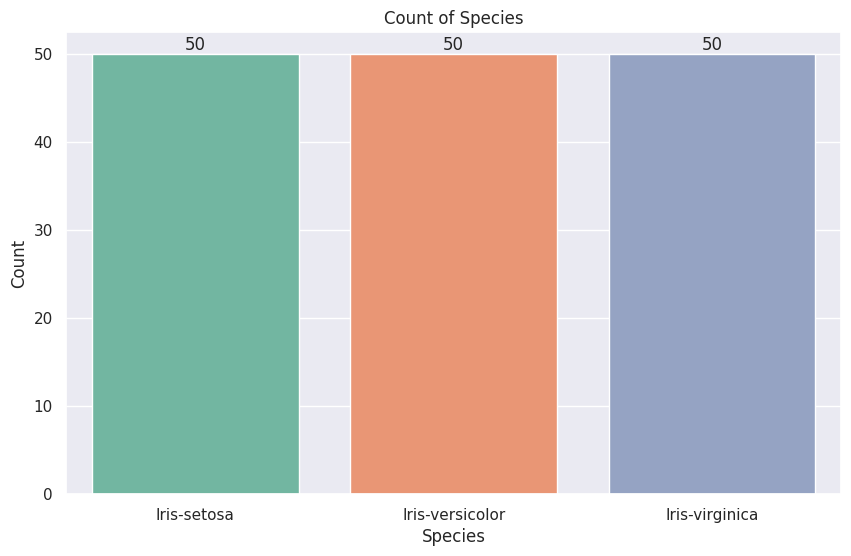

In [28]:
sns.countplot(data=df,
              x="Species",
              palette="Set2")
plt.xlabel("Species")
plt.ylabel("Count")
plt.title("Count of Species")
for i in range(3):
    plt.text(i, df["Species"].value_counts()[i],
             df["Species"].value_counts()[i],
             ha="center", va="bottom")
plt.show()

Interpretasi:
 - 3 grafik ini memilik tinggi yang sama menegaskan data seimbang
 - Model tidak bias kesalah satu kelas

### b) Petal Length vs Petal Width per Species

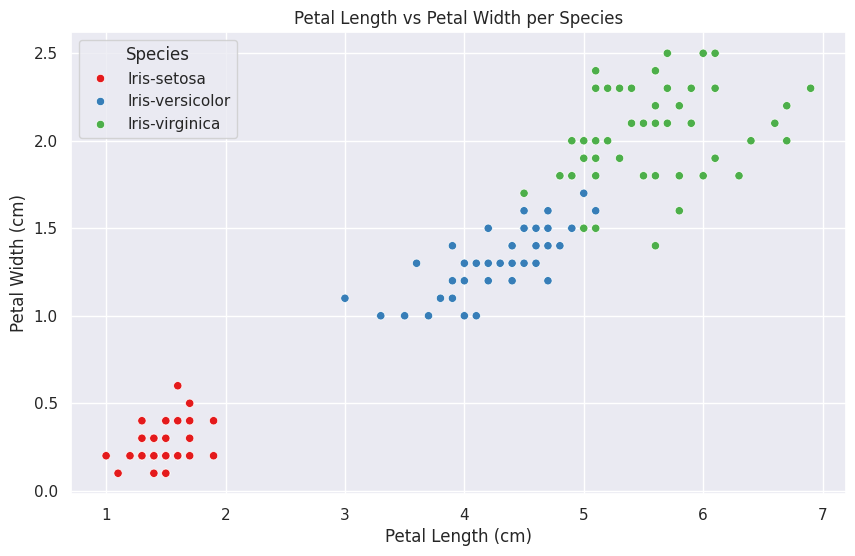

In [29]:
sns.scatterplot(data=df,
                x="PetalLengthCm",
                y="PetalWidthCm",
                hue="Species",
                palette="Set1")

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width per Species")
plt.show()

Interpretasi
  - `Sentosa` Terpisah di pojok kiri bawah
  - `Virginica` dan `VersiColor` terlihat sedikit tumpang tindih tetapi masih bisa dibedakan
  - Karna KNN berkerja berdasarkan Jarak, Pemisahan visual yang baik ini menjanjikan akurasi tinggi

  

### c) Sebaran tiap Fitur per Species ( BoxPlot )

/tmp/ipykernel_575/4075178881.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,
/tmp/ipykernel_575/4075178881.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,
/tmp/ipykernel_575/4075178881.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,
/tmp/ipykernel_575/4075178881.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,


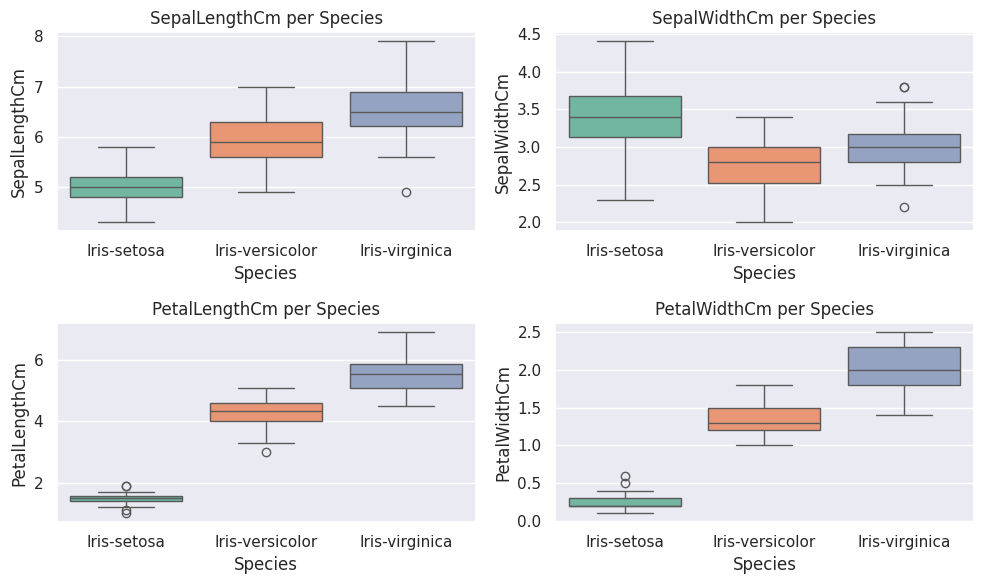

In [30]:
fitur = ["SepalLengthCm", "SepalWidthCm", "PetalLengthCm", "PetalWidthCm"]


fig,axes = plt.subplots(2,2)
for i in range(2):
    for j in range(2):
        sns.boxplot(data=df,
                    x="Species",
                    y=fitur[i*2+j],
                    ax=axes[i,j],
                    palette="Set2")
        axes[i,j].set_xlabel("Species")
        axes[i,j].set_ylabel(fitur[i*2+j])
        axes[i,j].set_title(f"{fitur[i*2+j]} per Species")
plt.tight_layout()
plt.show()


Interpretasi:

- Pemisahan yang Sangat Jelas pada Petal (Mahkota Bunga):

  - Pada grafik PetalLengthCm (kiri bawah) dan PetalWidthCm (kanan bawah), spesies Iris-setosa (hijau) sangat terpisah jauh dan memiliki ukuran yang jauh lebih kecil dibandingkan dua spesies lainnya.   
  - Hal ini menunjukkan bahwa ukuran kelopak mahkota (petal) adalah ciri pembeda utama yang membuat spesies Setosa sangat mudah dikenali.   
  
- Variasi pada Sepal (Kelopak Bunga):

  - Pada grafik SepalLengthCm (kiri atas) dan SepalWidthCm (kanan atas), ukuran antar spesies (Versicolor dan Virginica) agak saling tumpang tindih (overlap).   
  - Artinya, jika hanya mengandalkan ukuran kelopak luar (sepal), kedua spesies tersebut sedikit lebih sulit dibedakan dibandingkan saat menggunakan ukuran mahkotanya.

## Preprocessing: Encode Target, Split dan Scaling

Langkah:

1. **Encode** `Species` (teks) → angka dengan `LabelEncoder`.
2. **Split** 80/20 dengan stratify agar proporsi kelas terjaga.
3. **Scaling** — wajib untuk KNN karena algoritma ini mengukur **jarak**; fitur berskala besar akan mendominasi bila tidak distandardisasi.

In [31]:
#1. **Encode** `Species` (teks) → angka dengan `LabelEncoder`.
X = df.drop(columns=["Id", "Species"])
le = LabelEncoder()
y = le.fit_transform(df["Species"])

print("Mapping Kelas:", dict(zip(le.classes_, le.transform(le.classes_))))

Mapping Kelas: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}


In [32]:
#2. **Split** 80/20 dengan stratify agar proporsi kelas terjaga.
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    stratify=y,
                                                    random_state=42)

In [33]:
#3. **Scaling** — wajib untuk KNN karena algoritma ini mengukur **jarak**; fitur    berskala besar akan mendominasi bila tidak distandardisasi.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Data latih:", X_train.shape)
print("Data uji:", X_test.shape)



Data latih: (120, 4)
Data uji: (30, 4)


Interpretasi:
 - Target kini berupa angka 0/1/2. Setelah scaling, keempat fitur punya skala sebanding sehingga jarak antar titik adil.
 - Data sudah dibagi menjadi data uji dan data latih

## Mencari Nilai K terbaik

Parameter terpenting KNN adalah **k** (jumlah tetangga yang dilihat).

- k terlalu kecil → model sensitif terhadap noise (overfitting);
- k terlalu besar → model terlalu halus (underfitting).

Kita coba **k = 1..20** dan lihat akurasinya.

In [35]:
n_k = range(1,21)

ak_k = []

for k in n_k:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)

    y_pred = knn.predict(X_test_scaled)
    ak_k.append(accuracy_score(y_test, y_pred))

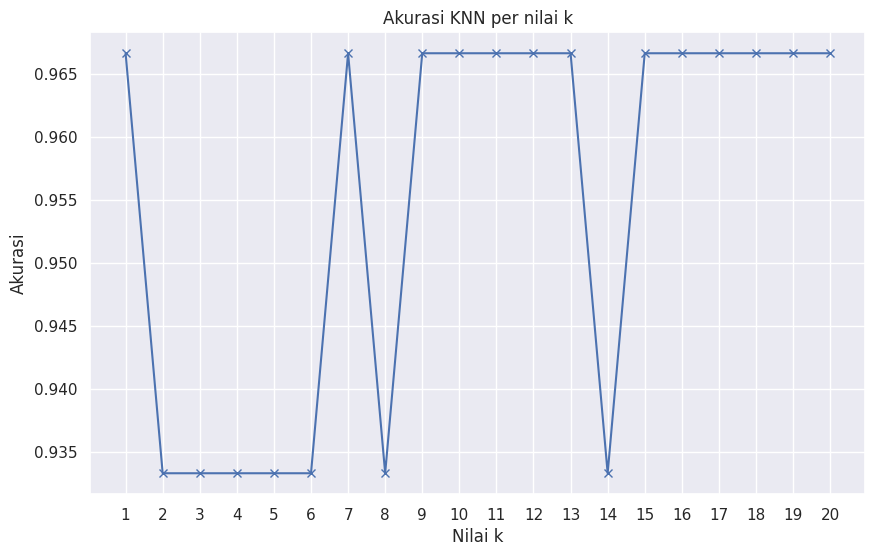

In [36]:
plt.plot(list(n_k),
         ak_k,
         marker='x')
plt.title("Akurasi KNN per nilai k")
plt.xlabel("Nilai k")
plt.ylabel("Akurasi")
plt.xticks(n_k)
plt.show()

In [41]:
k_best = list(n_k)[int(np.argmax(ak_k))]
print(f"Akurasi tertinggi:{max(ak_k):.2f} pada k={k_best}")

Akurasi tertinggi:0.97 pada k=1


Interpretasi:
- Grafik menunjukkan akurasi sangat tinggi pada rentang k menengah
- k yang sangat kecil bisa berfluktuatif
- gunakan dan pilih K terbaik dari hasil pencarian ini

## Modeling: Melatih KNN dengan K terbaik

In [42]:
model = KNeighborsClassifier(n_neighbors=k_best)
model.fit(X_train_scaled, y_train)


y_pred = model.predict(X_test_scaled)

print(f"Akurasi Model (k{k_best}): {accuracy_score(y_test, y_pred):.2f}")

Akurasi Model (k1): 0.97


Interpretasi:
- Dengan K yang OptimaL
- KNN mengklasifikasikan spesies IRIS dengan akurasi sangat tinggi

## Evaluasi Model

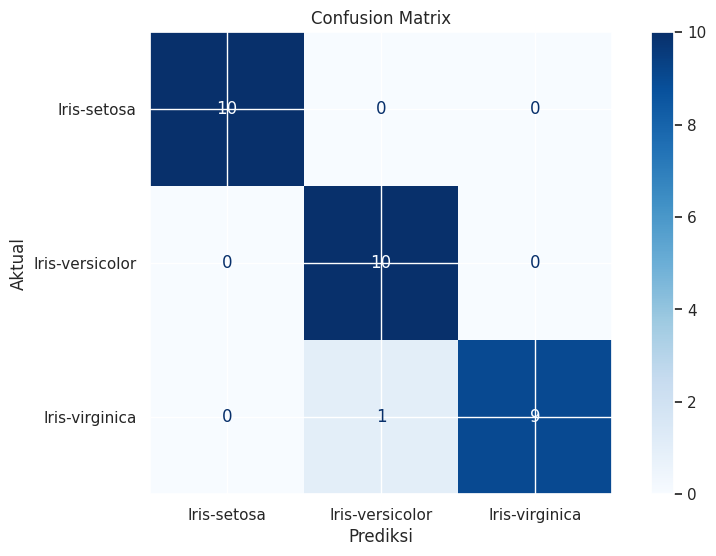

In [43]:
con_mat = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=con_mat,
                              display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.title("Confusion Matrix")
plt.show()

Interpretasi:

- Sangat Akurat:

  - Semua bunga Iris-setosa (10 data) dan Iris-versicolor (10 data) berhasil ditebak dengan benar tanpa ada kesalahan sama sekali.

- Sedikit Meleset pada Virginica:

  - Dari total 10 data Iris-virginica, sebanyak 9 data berhasil ditebak dengan benar, namun ada 1 data yang keliru diprediksi sebagai Iris-versicolor.

Secara keseluruhan, model memiliki tingkat akurasi yang sangat tinggi karena hampir seluruh prediksinya tepat berada di diagonal utama.

In [44]:
print(classification_report(y_test,
                            y_pred,
                            target_names=le.classes_))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.91      1.00      0.95        10
 Iris-virginica       1.00      0.90      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



Interpretasi:

- Akurasi Sangat Tinggi (0.97 atau 97%):
  - Secara keseluruhan, model berhasil menebak jenis bunga dengan benar pada 29 dari 30 total data uji.

- Iris-setosa (Sempurna):
  - Model mengenali seluruh bunga setosa dengan sangat tepat tanpa ada kesalahan (skor 1.00 untuk precision, recall, dan f1-score).

- Iris-versicolor:
  - Semua bunga versicolor berhasil ditemukan oleh model (recall 1.00), tetapi dari semua yang ditebak sebagai versicolor, ada sedikit kesalahan kecil (precision 0.91) karena ada satu bunga jenis lain yang ikut masuk ke kategori ini.

- Iris-virginica:
  - Semua tebakan model untuk virginica sudah pasti benar (precision 1.00), namun ada 1 bunga virginica yang gagal terdeteksi dan terlewat oleh model (recall 0.90).

## Kesimpulan dan Insight

Berikut adalah poin-poin kesimpulan dan insight utama dari eksperimen klasifikasi multi-class ini:

1. **Kualitas Dataset (Iris Dataset):**
   - Dataset ini sangat seimbang (*perfectly balanced*) dengan masing-masing kelas target memiliki tepat 50 sampel. Hal ini membuat model tidak bias ke kelas tertentu saat proses pelatihan.
   - Tidak ditemukan nilai yang hilang (*missing values*), sehingga tidak memerlukan proses imputasi data.

2. **Karakteristik Fitur Fisik (Insight EDA):**
   - Fitur **Petal (mahkota bunga)**, baik panjang maupun lebarnya, merupakan pembeda utama (*key discriminators*) yang sangat kuat. Spesies *Iris-setosa* dapat dipisahkan secara sempurna hanya dengan mengamati dimensi kelopak mahkotanya.
   - Fitur **Sepal (kelopak luar)** memiliki tingkat tumpang tindih (*overlap*) yang tinggi antara *Iris-versicolor* dan *Iris-virginica*, sehingga kurang efektif jika diandalkan secara mandiri.

3. **Pentingnya Preprocessing:**
   - Langkah standardisasi skala (*scaling*) menggunakan `StandardScaler` sangat krusial sebelum menggunakan algoritma berbasis jarak seperti KNN agar fitur dengan rentang nilai besar tidak mendominasi perhitungan jarak.

4. **Performa Model KNN:**
   - Dengan pencarian nilai $k$ terbaik, didapatkan akurasi yang sangat tinggi yaitu **97%** pada data uji ($k=1$).
   - **Analisis Detail (Confusion Matrix & Classification Report):**
     - Kelas **Iris-setosa** berhasil diklasifikasikan dengan sempurna (Precision, Recall, F1-Score = 1.00).
     - Terdapat sedikit ambiguitas antara **Iris-versicolor** dan **Iris-virginica** karena kemiripan bentuk fisiknya, di mana ada 1 data *Iris-virginica* yang terprediksi salah sebagai *Iris-versicolor*.